# 07 — Sequence models

**Dataset:** `drive_day_2026`

**Question:** Does compact GRU prediction beat persistence on held-out recordings?

## Method

Train next-sample GRU on training windows and compare against unchanged-value persistence.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_learned import render_sequence_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "drive_day_2026"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,07173121b1534f1eadb8b127005d4eff70872388074c2b...,21.9,moving_candidate,False,recorded_time_column,train
1,1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316...,21.9,moving_candidate,False,recorded_time_column,train
2,1cca7c275163fc193899535ebb0c13f26676e8568d3c8a...,37.9,moving_candidate,False,recorded_time_column,train
3,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,57.8,moving_candidate,False,recorded_time_column,train
4,25aa01e1dcbaea32c062e01b0f782c938c34163fc58af1...,73.7,moving_candidate,False,recorded_time_column,train
5,2f775054c4e7bb342cf49e0ee66406e82353c274c103fc...,25.9,moving_candidate,False,recorded_time_column,train
6,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,57.8,stationary_candidate,True,recorded_time_column,train
7,4c8d0190b666e26315ce16c862ca2e968d576e14537487...,21.9,moving_candidate,False,recorded_time_column,train
8,554af5ad576c1c1d069356649e3bd1e2699a5801f6a0fa...,17.9,stationary_candidate,True,recorded_time_column,train
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,57.8,stationary_candidate,True,recorded_time_column,train


In [2]:
EXPERIMENT_OPTIONS = {'epochs': 20}
EXPERIMENT_OPTIONS

{'epochs': 20}

,task,split,metric,value,sample_count,reference_source
0,next_sample_prediction,train,gru_mse,0.226287,333,none
1,next_sample_prediction,validation,gru_mse,0.191583,108,none
2,next_sample_prediction,test,gru_mse,0.180149,59,none
3,next_sample_prediction,all,gru_mse,0.213347,500,none
4,next_sample_prediction,train,persistence_mse,0.092579,333,persistence_baseline
5,next_sample_prediction,validation,persistence_mse,0.081219,108,persistence_baseline
6,next_sample_prediction,test,persistence_mse,0.094482,59,persistence_baseline
7,next_sample_prediction,all,persistence_mse,0.090350,500,persistence_baseline


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,500,21,667a6e15a4394db30d7cce7a4db319041453bfa306b566...,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,500,500,window_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,500.0,NaN,NaN,NaN,43.528,49.015163,0.0,11.5,27.0,54.0,218.0
end_s,500.0,NaN,NaN,NaN,53.528,49.015163,10.0,21.5,37.0,64.0,228.0
prediction_kind,500,1,sequence_prediction_error,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,500.0,NaN,NaN,NaN,0.213347,0.282107,0.006877,0.011823,0.109201,0.254488,1.253944
label_status,500,1,provisional_unverified,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
persistence_error,500.0,NaN,NaN,NaN,0.09035,0.128333,0.000001,0.00241,0.034458,0.119595,0.65065


,count,mean,median,std,min,max
recording_id,,,,,,
67460352e955edbaf8a0e73406f2aa4726aa14abea0a93abbe0484dccf14d5c3,15,0.434238,0.501255,0.288681,0.057656,0.835400
e57d3de89d6f2a3165aa05beee7b611f60923e090254337c1b48f744c78db52d,24,0.313230,0.332558,0.284935,0.007508,0.865840
667a6e15a4394db30d7cce7a4db319041453bfa306b566a87e84b213d81efb29,110,0.380591,0.262378,0.320366,0.006877,1.253944
5e9e04831922d971561f6ffb53b2c77744d905cca01dcc2fe043d10b2f63c613,16,0.261423,0.214092,0.167118,0.109187,0.596821
07173121b1534f1eadb8b127005d4eff70872388074c2bbe0c93061527d89f40,7,0.251111,0.210067,0.136559,0.164514,0.558449
1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316416ecbf000289fd40a,7,0.190733,0.188622,0.019575,0.170334,0.223713
4c8d0190b666e26315ce16c862ca2e968d576e14537487162bbd73b9a47d0c07,7,0.202981,0.165165,0.064303,0.125453,0.272717
f8a2dfe19bc591bed40778fcb493d9a34a3261518b2f4b416ba15a9402ec6dd7,16,0.132620,0.151023,0.070246,0.009577,0.234625
2f775054c4e7bb342cf49e0ee66406e82353c274c103fc7f7d6a93ea329aea86,9,0.141816,0.133248,0.042722,0.064299,0.191933


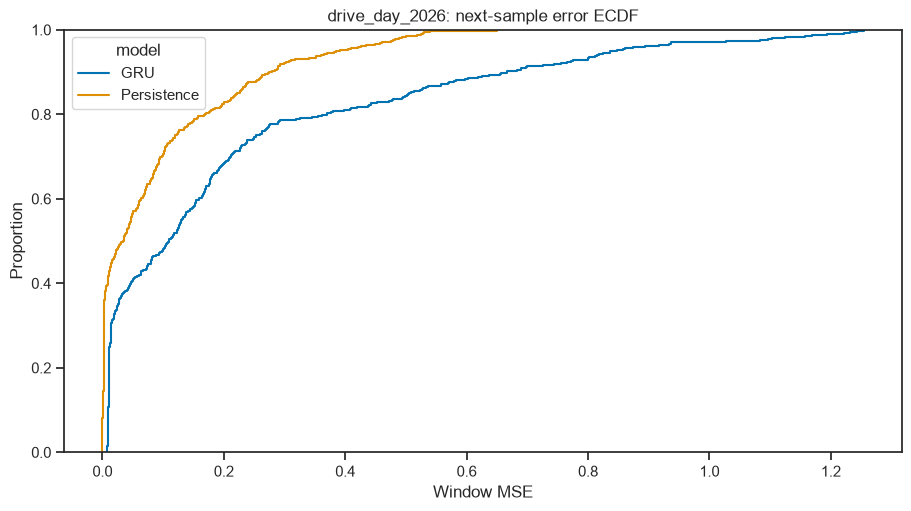

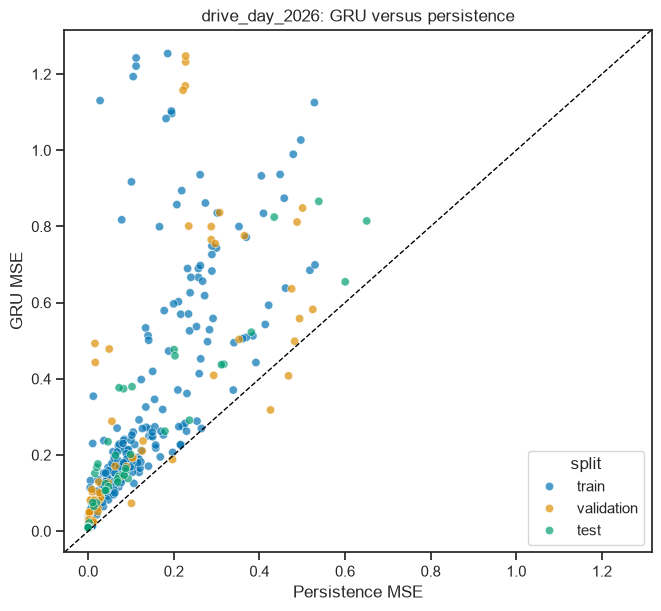

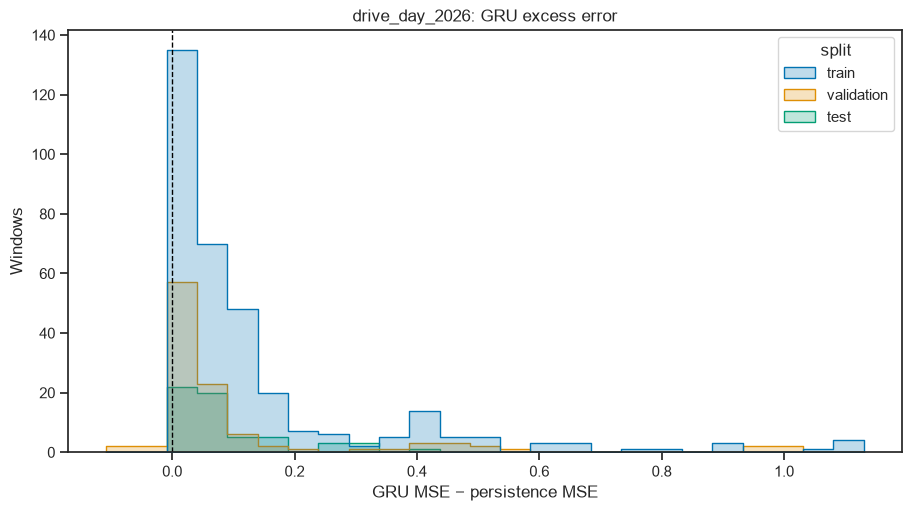

C:\Users\randl\Documents\GitHub\Lap_Estimation\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


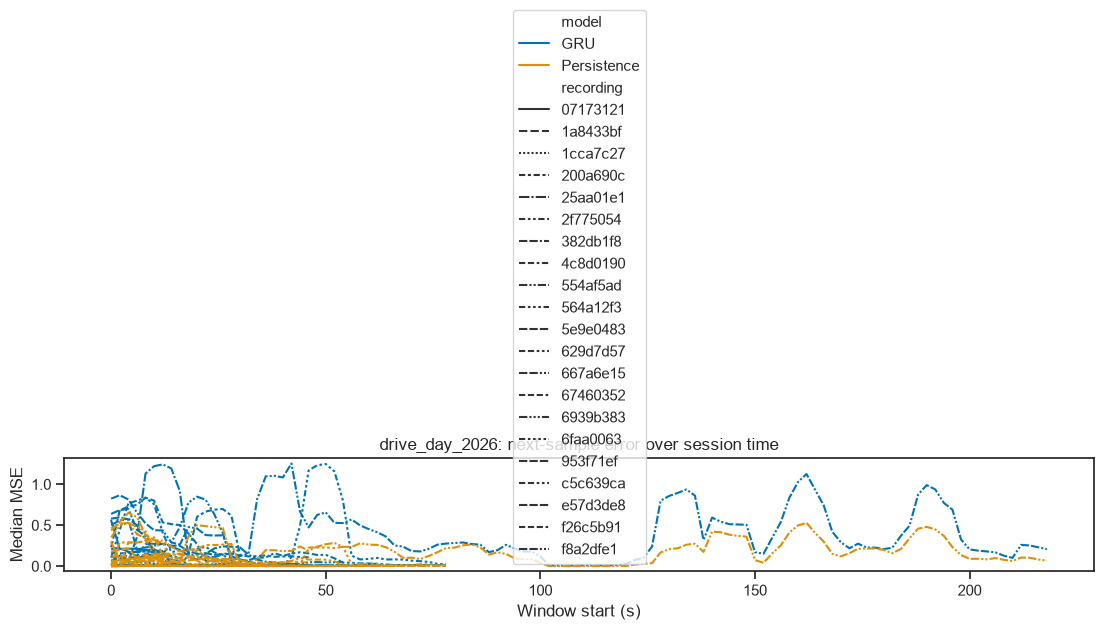

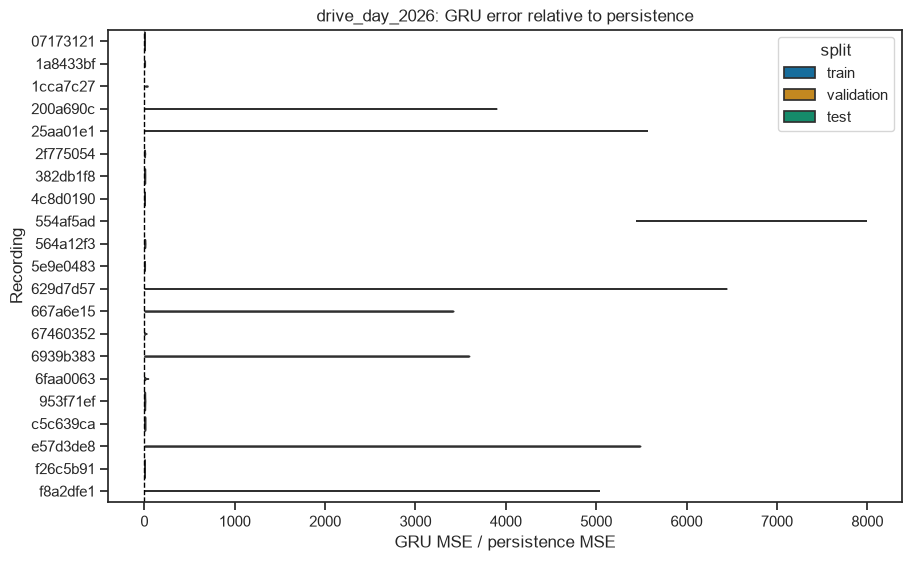

In [3]:
METHOD = "07_sequence_models"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_sequence_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,6.142
clock_provenance,recorded_time_column
sample_rate_hz,10.0
channels,"[Motor RPM [Rpm], MC Duty Cycle [%], AC Curren..."
label_provenance,prediction_error_unverified


## Reading

GRU must beat persistence before recurrent state deserves further use.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.